## Setup

In [1]:
!pip install git+https://github.com/huggingface/diffusers.git -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Inference

In [12]:
# Imports and setting the shared prompt
import torch
import gc
from diffusers import DiffusionPipeline, AutoencoderKL
PROMPT = "Bill Gates in Naruto style"
DEVICE = "cuda"
BASE_MODEL = "stabilityai/stable-diffusion-xl-base-1.0"
VAE_MODEL = "madebyollin/sdxl-vae-fp16-fix"

# Load the VAE
vae = AutoencoderKL.from_pretrained(
    VAE_MODEL,
    torch_dtype=torch.float16
)

# Function to free the GPU after every pipeline run
def free_gpu():
    del globals()["pipe"]
    torch.cuda.empty_cache()
    gc.collect()

# Creating and loading the sdxl pipeline
def load_sdxl_pipeline():
    pipe = DiffusionPipeline.from_pretrained(
        BASE_MODEL,
        vae=vae,
        torch_dtype=torch.float16,
        variant="fp16",
        use_safetensors=True
    ).to(DEVICE)
    return pipe


In [13]:
# Dreambooth Pipeline
dreambooth_repo = "sprodem/Naruto_Drambooth_LoRA"

pipe = load_sdxl_pipeline()
pipe.load_lora_weights(dreambooth_repo)

dreambooth_image = pipe(
    prompt=PROMPT,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

dreambooth_image
free_gpu()


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/25 [00:00<?, ?it/s]

In [14]:
# SDXL LORA Pipeline
naruto_lora_repo = "sprodem/sdxl-naruto-lora"

pipe = load_sdxl_pipeline()
pipe.load_lora_weights(naruto_lora_repo)

naruto_lora_image = pipe(
    prompt=PROMPT,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

naruto_lora_image
free_gpu()


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/25 [00:00<?, ?it/s]

In [15]:
# Original SDXL Pipeline
pipe = load_sdxl_pipeline()

orig_image = pipe(
    prompt=PROMPT,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

orig_image
free_gpu()


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

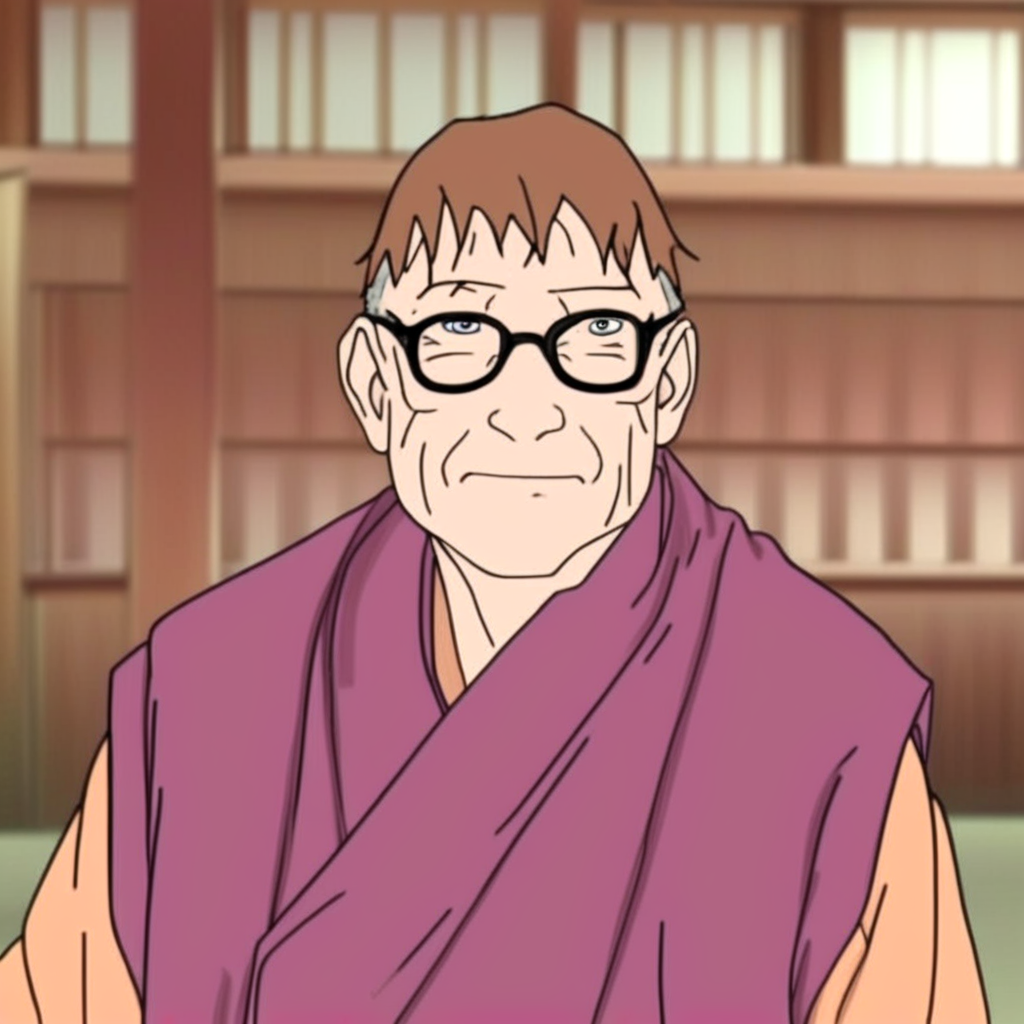

In [16]:
dreambooth_image

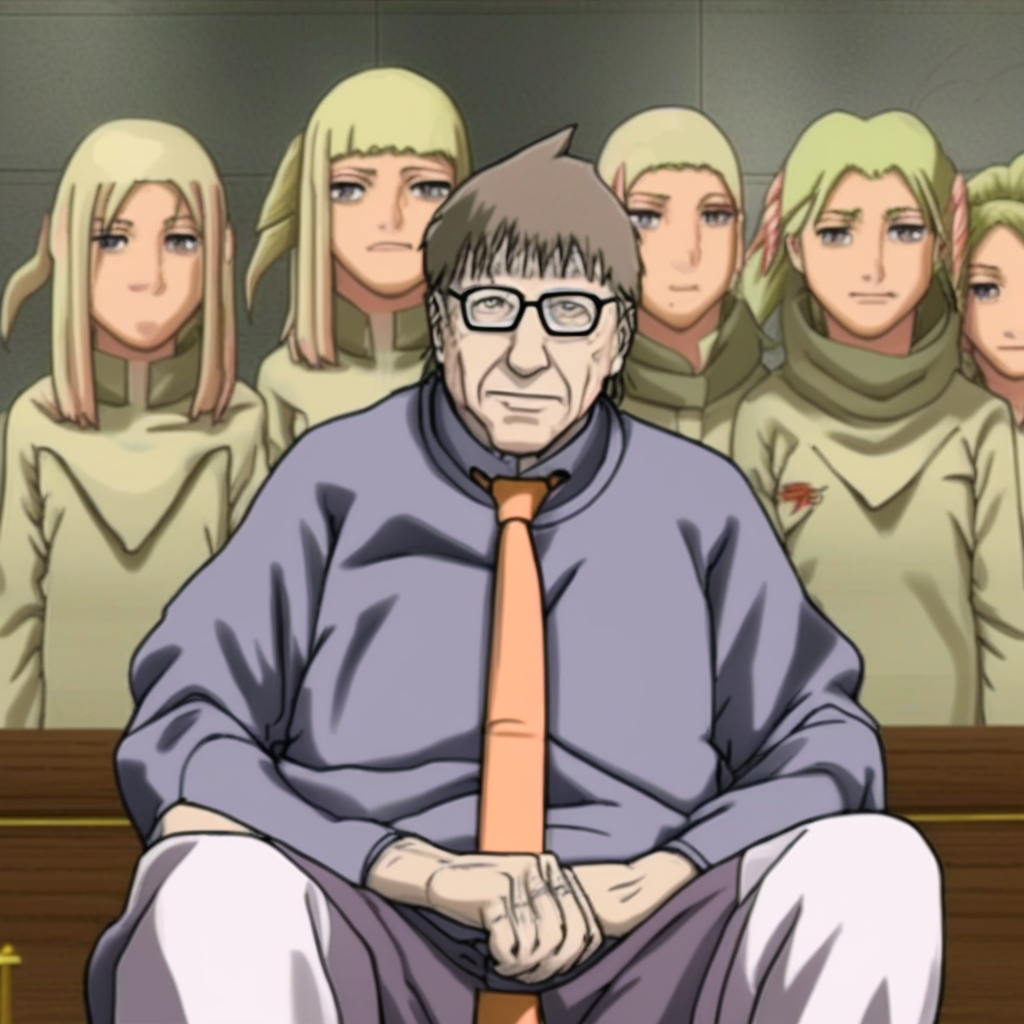

In [17]:
naruto_lora_image

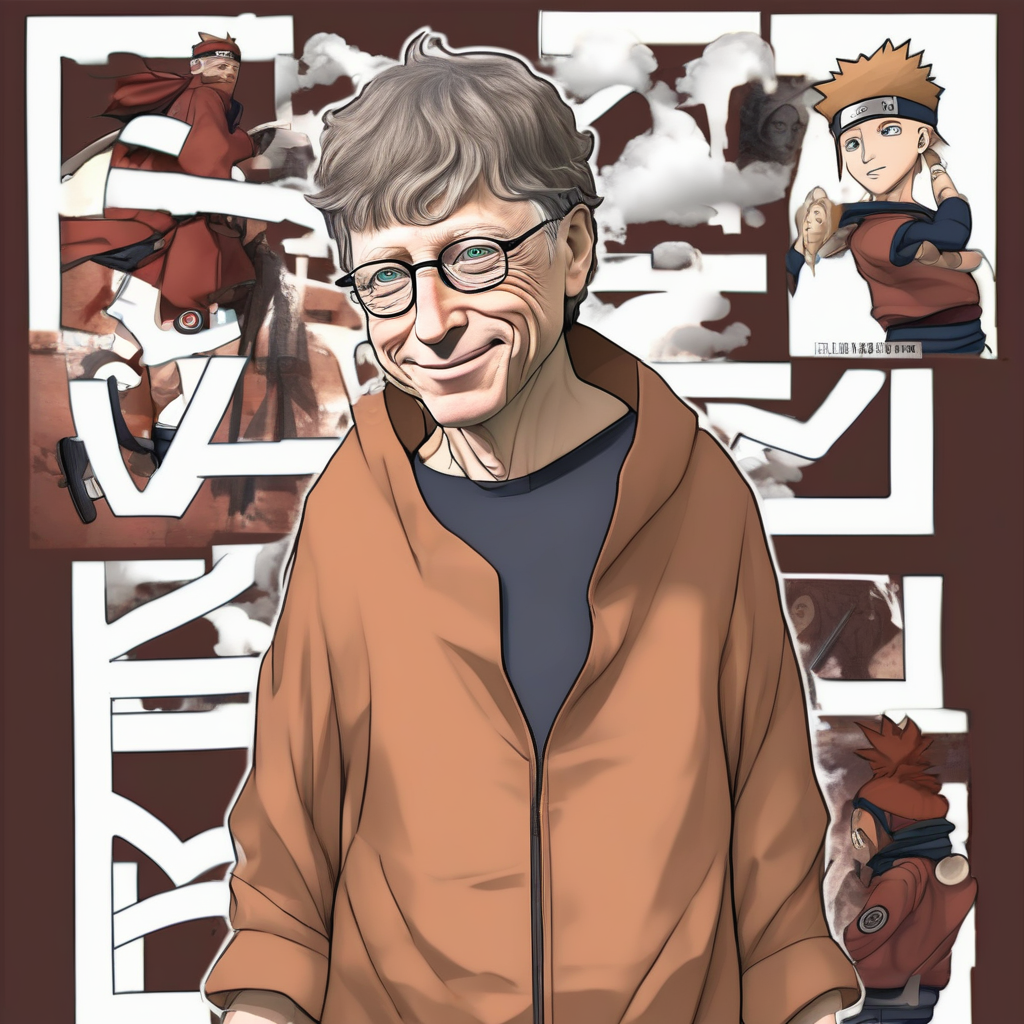

In [18]:
orig_image